# Data Transformation for Model Creation

## Feature Engineering

### Factor Analysis

#### 1. Example Scenario
- 3 survey questions a company asks 5 customers:
  | Question                | Variable |
  |-------------------------|----------|
  | Q1: Product quality     | x1       |
  | Q2: Delivery experience | x2       |
  | Q3: Customer support    | x3       |
- Each answer ranges from number **1** to **5**
- x1, x2, and x3 are **observed variables**

In [9]:
import pandas as pd

df = pd.DataFrame({
    'Customer': [1,2,3,4,5],
    'x1': [5,4,1,2,4],
    'x2': [4,4,2,1,5],
    'x3': [3,2,4,3,3]
    })

print(df.to_string(index=False))

 Customer  x1  x2  x3
        1   5   4   3
        2   4   4   2
        3   1   2   4
        4   2   1   3
        5   4   5   3


#### 2. Exploratory Data Analysis \(EDA\)

In [10]:
# Correlation matrix
print(df.iloc[:, 1:].corr())

          x1        x2        x3
x1  1.000000  0.814815 -0.645497
x2  0.814815  1.000000 -0.430331
x3 -0.645497 -0.430331  1.000000


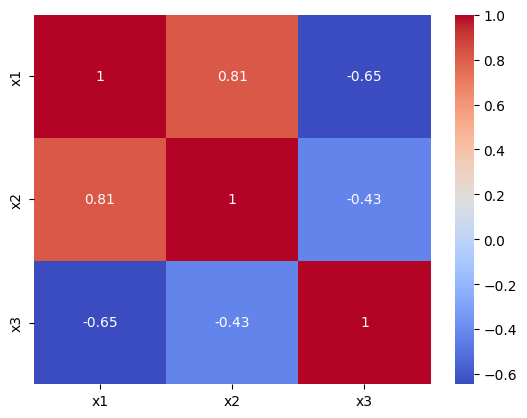

In [11]:
# Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.iloc[:, 1:].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

- x1 and x2 are strongly correlated
- x3 is weakly related

#### 3. Factor Analysis \(FA\)
- FA is a technique for finding hidden patterns that explain why several variables tend to move together
- Instead of treating x1, x2, and x3 independently, FA assumes that there may be some latent factor causing x1 and x2 to move together, which is F1 \(factor 1, **common factors**\)

- Then, each observed variable in FA will look like:
  - x1 = a1 * F1 + e1
  - x2 = b1 * F1 + e2
  - x3 = c1 * F1 + e3
  > Observed variable = common factors (shared) + unique noise

- Common factors \(F1\)
  - F1 is NOT in the dataset; it is inferred from patterns—a **latent** variable
  - To apply this concept to our example scenario:
    | Customer | F1 \(latent\) |
    |----------|---------------|
    | 1        | High          |
    | 2        | Medium        |
    | 3        | Low           |
    | 4        | Low           |
    | 5        | Medium        |
  - F1 changes from data point to data point; each observation has its own numerical value of F1, and it is NOT a constant
  - Domain knowledge comes into the picture in the process of interpretation **after** the math is done \(e.g., F1 may be product satisfaction\)

- a1, b1, and c1 are **factor loadings** \(weights\); they represent how strongly each variable depends on them
  - Although we have found out that x3 is weakly correlated, FA does not remove F1 from x3; c1 will be very small \(close to 0\), compared with a1 or b1
  - F1 is expressed purely as a weighted sum of loadings such as a1, b1, and c1

- e1, e2, and e3 are noise **unique to** each observed variable
  - These do not create correlation and affect individual variables only

- FA works only in **linear** relationship, meaning that if one thing increases, another thing changes proportionally and smoothly
  - F1 cannot be F1², F1³, or log(F1)
  - If there are more than one common factors \(e.g., F1 and F2\), x = a1 * F1 * F2 is not allowed

#### 4. Application in Python

##### 4.1. Business Question
> "With the survey data we collected from customers, can we predict whether a customer will buy the product again?"
- Target variable: Did the customer buy the product again?
  - Yes: 1
  - No: 0

##### 4.2. Python

In [15]:
# Scikit-learn (Basics)
import numpy as np
from sklearn.decomposition import FactorAnalysis

# Example data (same as df in our example scenario)
X = np.array([
    [5, 4, 3],
    [4, 4, 2],
    [1, 2, 4],
    [2, 1, 3],
    [4, 5, 3]
])

# Create model (assume 1 factor)
fa = FactorAnalysis(n_components=1)

# Fit the model
fa.fit(X)

# See factor loadings (weights)
print(fa.components_)

# See F1 values per observation
print(fa.transform(X))

[[-1.41363795 -1.23075206  0.4076115 ]]
[[-1.04126438]
 [-0.62767328]
 [ 1.41038424]
 [ 0.89788632]
 [-0.63933289]]


- `fa.components_` gives you a1, b1, and c1 \(i.e., factor loadings of x1, x2, and x3 given that there is only one common factor, F1)
  - In other words, each observed variable can be expressed as:
      - x1 = -1.41363795 * F1 + e1
      - x2 = -1.23075206 * F1 + e2
      - x3 = 0.4076115 * F1 + e3
  - You can see that absolute values of x1 and x2 loadings are larger than x3's; it means that x1 and x2 strongly depend on F1 whereas x3 weakly depends on F1
  - The sign \(\+ or \-\) simply means that x1 and x2 tend to decrease when F1 increases while x3 tends to increase, and what matters is the **magnitude**; when F1 changes, x1 and x2 change much more than x3 does

- `fa.transform(X)` tells you where each customer lies on the axis of F1—actual representation of data
  - F1\(Customer 1\) = -1.04126438
  - F1\(Customer 2\) = -0.62767328
  - ...
  - F1\(Customer 5\) = -0.63933289

- Based on the results from `fa.components_` and `fa.transform(X)`, we can mathematically compute e1, e2, and e3
  - For example, e1 of customer 1 is:
    - Actual x1 = 5
    - 5 = -1.41363795 * -1.04126438 + e1
    - e1 ≈ 5 - 1.47 = 3.53 \(residual or unexplained part\)
  - However, it is usually NOT useful in modelling because:
    - It is not stable across data
    - Noise is random
  - Therefore in practice, we only care about common factor \(F1\), and independent variables not well explained by the factor \(x3\) should be retained alongside F1 for better modelling performance
    - Dimension reduction is from `[x1, x2, x3]` to `[F1, x3]`

In [ ]:
df = pd.DataFrame({
    'Customer': [1,2,3,4,5],
    'x1': [5,4,1,2,4],
    'x2': [4,4,2,1,5],
    'x3': [3,2,4,3,3],
    'Bought again?': [1, 1, 0, 0, 1]    # Target variable (y)
    })

print(df.to_string(index=False))

 Customer  x1  x2  x3  Bought again?
        1   5   4   3              1
        2   4   4   2              1
        3   1   2   4              0
        4   2   1   3              0
        5   4   5   3              1


Model: `y = f(F1, x3)`
- F1 captures main customer behaviour, and x3 adds extra independent info or secondary influence; if F1 is **low**, customer has been satisfied and is likely to buy again
- Benefits of dimension reduction:
  - Fewer variables
  - Cleaner structure
  - Less noise
  - Removed redundancy
- How many features to choose \(reduce from FA\) is a trade-off between:
  - Simple vs. slightly more complex model
  - Better predictive power vs. worse accuracy \(especially if x3 matters\)

However, `scikit-learn (sklearn)` FA cannot carry out full statistical analysis and does not support rotation
  - Rotation means slightly rotating the axis to better align with the data
    - Rotation changes neither the data nor F1 values fundamentally
    - It is intended to group variables into groups of common factors
  - Actual data might look messy like this:
    | Variable | F1  | F2  |
    |----------|-----|-----|
    | x1       | 0.6 | 0.5 |
    | x2       | 0.7 | 0.4 |
    | x3       | 0.5 | 0.6 |
    | x4       | 0.4 | 0.7 |
  - Rotation tries to turn this into something like this:
    | Variable | F1  | F2  |
    |----------|-----|-----|
    | x1       | 0.9 | 0.1 |
    | x2       | 0.8 | 0.2 |
    | x3       | 0.1 | 0.9 |
    | x4       | 0.2 | 0.8 |
  - Rotation becomes important when there are two or more factors
  - When rotation comes into the workstream, pipeline will look like EDA -> FA -> Rotation *\(optional\)* -> Interpretation -> Modelling

For rotation, `factor_analyzer` is a better tool than `sklearn`

### AI Transparency Statement
This notebook is part of my learning journey in exploratory analysis and factor analysis. I worked through the concepts step by step, starting from correlation analysis to factor analysis and its application in modelling. Throughout the process, I used M365 Copilot as a learning aid—asking questions, validating my understanding, and exploring different examples. All explanations, code structure, and interpretations here are written in my own words based on what I learned and understood during the process. The goal of this notebook is not only to demonstrate the implementation of factor analysis, but also to show how I think about connecting theory to practical data science workflows.